# Week 3 – Image Encodings & HOG

## Objective
Understand **hand-crafted image encodings** and how Histogram of Oriented Gradients (HOG)
represents visual structure in images.

**Instructions**
- Read the markdown carefully
- Fill in cells marked with `TODO`
- Do NOT change cell order


In [3]:
# TODO: Import required libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog


## Step 1: Load Vehicle Damage Dataset
We use a **small curated subset** of the vehicle damage dataset provided by mentors. If by chance this part is confusing to you, because we haven't explicitly covered it, please ask for help.

In [9]:
# TODO: Load a few vehicle damage images from the dataset folder
# Convert images to grayscale
# Resize images to a fixed size (e.g., 128x128)
IMAGE_DIR = "D:/archive/image/image"
IMAGE_SIZE = (128, 128)

images = []

# take only first 5 images (change number if you want)
for filename in os.listdir(IMAGE_DIR)[:50]:
    img_path = os.path.join(IMAGE_DIR, filename)

    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, IMAGE_SIZE)

    images.append(resized)

print(len(images))

50


## Step 2: Compute HOG Features
HOG captures gradient orientation information in localized regions.


In [10]:
hog_features = []
hog_images = []

for img in images:
    features, hog_image = hog(
        img,
        visualize=True,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        orientations=9
    )
    hog_features.append(features)
    hog_images.append(hog_image)


## Step 3: Visualize HOG Representation
Compare the original image with its HOG visualization.


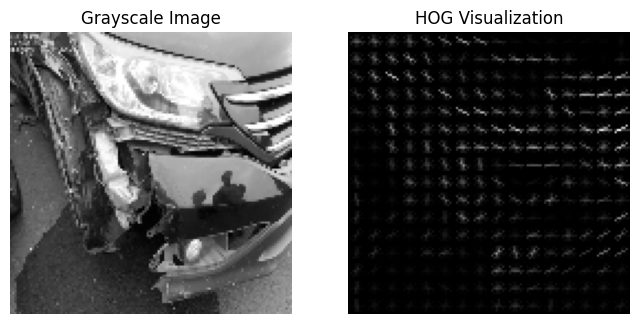

In [11]:
# TODO: Plot original image and corresponding HOG image
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(images[0], cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_images[0], cmap="gray")
plt.title("HOG Visualization")
plt.axis("off")

plt.show()


## Step 4: Dimensionality Reduction
Apply PCA or t-SNE to HOG feature vectors to visualize structure.


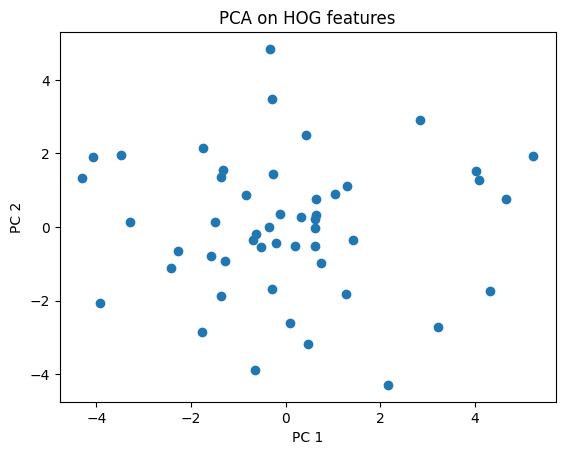

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(hog_features)

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA on HOG features")
plt.show()


## Reflection
- What visual information does HOG preserve?
- Why might HOG struggle with complex damage patterns?
HOG preserves local edge orientation statistics but lacks the ability to capture irregular, non-repetitive, and texture-dominated damage patterns, leading to poor separability for complex defects
